# 01 — Preprocessing AV45
Aquesta notebook construeix el dataset processat d'**AV45** a partir dels NIfTI descarregats i de les etiquetes clíniques CDR d'OASIS-3.

L'objectiu és deixar guardats fitxers `.npy` i `.csv` nets per a les notebooks d'EDA, Machine Learning i CNN.

**Què es fa:**

1. Carregar les etiquetes clíniques CDR.
2. Localitzar els fitxers NIfTI d'AV45.
3. Extreure `OASISID`, dia de sessió i traçador.
4. Associar cada imatge amb la visita clínica més propera.
5. Carregar el PET i convertir-lo de 4D a 3D si cal.
6. Detectar imatges corruptes o amb `NaN`.
7. Normalitzar cada volum.
8. Filtrar per la shape dominant.
9. Redimensionar a `128x128x64`.
10. Guardar `X`, `y`, metadata i logs de qualitat.

> Important: si una imatge conté `NaN` o infinits, es descarta per defecte. Aquest control permet descartar qualsevol imatge problemàtica abans de guardar el dataset final.

In [1]:
# =========================
# 0. IMPORTS I LLAVOR ALEATÒRIA
# =========================
import os
import re
import random
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy.ndimage import zoom
from collections import Counter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [2]:


BASE_AV45 = r"D:\Universidad\TFG\OASIS\av45"

BASE_UDS = r"D:\Universidad\TFG\OASIS\extraDAta\www.nitrc.org\ir\OASIS3\0AS_data_files\OASIS3_data_files\UDSb4\csv"
UDS_CDR_PATH = os.path.join(BASE_UDS, "OASIS3_UDSb4_cdr.csv")

OUT_DIR = r"D:\Universidad\TFG\OASIS"
os.makedirs(OUT_DIR, exist_ok=True)

TARGET_SHAPE = (128, 128, 64)

MAX_DAYS_DIFF = 365

DROP_IMAGES_WITH_NAN_OR_INF = True

print("OUT_DIR:", OUT_DIR)
print("TARGET_SHAPE:", TARGET_SHAPE)


OUT_DIR: D:\Universidad\TFG\OASIS
TARGET_SHAPE: (128, 128, 64)


## 2. Carregar etiquetes clíniques CDR

S'utilitza la columna `CDRTOT`:

- `CDRTOT = 0` → subjecte sa / sense deteriorament clínic.
- `CDRTOT > 0` → subjecte amb deteriorament cognitiu.

L'etiqueta s'assigna a cada PET utilitzant la visita CDR més propera en el temps, sempre que es trobi dins d'una finestra màxima de `MAX_DAYS_DIFF` dies.


In [3]:
# =========================
# 2. CÀRREGA D'ETIQUETES CDR
# =========================

df_uds = pd.read_csv(UDS_CDR_PATH)

ID_COL = "OASISID"
DAY_COL = "days_to_visit"
CDR_COL = "CDRTOT"

df_labels = df_uds[[ID_COL, DAY_COL, CDR_COL]].copy()
df_labels = df_labels.dropna(subset=[ID_COL, DAY_COL, CDR_COL])

df_labels[ID_COL] = df_labels[ID_COL].astype(str).str.strip()
df_labels[DAY_COL] = pd.to_numeric(df_labels[DAY_COL], errors="coerce")
df_labels[CDR_COL] = pd.to_numeric(df_labels[CDR_COL], errors="coerce")

df_labels = df_labels.dropna().copy()
df_labels["label_binaria"] = (df_labels[CDR_COL] > 0).astype(int)

print("Labels clínicas cargadas:", df_labels.shape)
print(df_labels["label_binaria"].value_counts())
df_labels.head()


Labels clínicas cargadas: (8625, 4)
label_binaria
0    6479
1    2146
Name: count, dtype: int64


,OASISID,days_to_visit,CDRTOT,label_binaria
0,OAS30001,0,0.0,0
1,OAS30001,339,0.0,0
2,OAS30001,722,0.0,0
3,OAS30001,1106,0.0,0
4,OAS30001,1456,0.0,0


## 3. Funcions auxiliars

Aquestes funcions permeten reutilitzar el mateix procés per a AV45.

S'analitzen rutes amb una estructura del tipus:

- `OAS30001_AV45_d2430`
- `sub-OAS30001_ses-d2430_acq-AV45_pet.nii.gz`


In [4]:
# =========================
# 3. FUNCIONS AUXILIARS
# =========================

def encontrar_niftis(base_path):
    """Retorna tots els fitxers .nii o .nii.gz dins d'una carpeta."""
    niftis = []
    for root, _, files in os.walk(base_path):
        for f in files:
            if f.endswith(".nii") or f.endswith(".nii.gz"):
                niftis.append(os.path.join(root, f))
    return sorted(niftis)


def parsear_nifti(ruta, tracer_esperado=None):
    """
    Extrae OASISID, día y trazador desde filename o ruta.
    Devuelve None si no puede parsear o si el tracer no coincide.
    """
    fname = os.path.basename(ruta)
    texto = ruta

    # Patró BIDS: sub-OAS30001_ses-d2430_acq-AV45_pet.nii.gz
    m = re.search(r"sub-(OAS\d+)_ses-d(\d+)_acq-([A-Za-z0-9]+).*pet", fname, re.IGNORECASE)
    if m:
        oasisid = m.group(1)
        day = int(m.group(2))
        tracer = m.group(3).upper()
    else:
        # Patró per carpeta: OAS30001_AV45_d2430
        m = re.search(r"(OAS\d+)_([A-Za-z0-9]+)_d(\d+)", texto, re.IGNORECASE)
        if not m:
            return None
        oasisid = m.group(1)
        tracer = m.group(2).upper()
        day = int(m.group(3))

    if tracer_esperado is not None and tracer != tracer_esperado.upper():
        return None

    return {
        "ruta_imagen": ruta,
        "filename": fname,
        "OASISID": oasisid,
        "days_from_entry": day,
        "tracer": tracer
    }


def construir_dataframe_imagenes(base_path, tracer):
    """Construeix un dataframe amb totes les sessions PET trobades per a un traçador."""
    rows = []
    for ruta in encontrar_niftis(base_path):
        parsed = parsear_nifti(ruta, tracer_esperado=tracer)
        if parsed is not None:
            rows.append(parsed)

    if len(rows) == 0:
        return pd.DataFrame(columns=["ruta_imagen", "filename", "OASISID", "days_from_entry", "tracer"])

    return (
        pd.DataFrame(rows)
        .drop_duplicates(subset=["OASISID", "tracer", "days_from_entry", "filename"])
        .reset_index(drop=True)
    )


def encontrar_label_mas_cercano(row, df_labels, max_days_diff=365):
    """
    Busca la visita CDR más cercana temporalmente a la imagen PET.
    Devuelve label, CDR real y diferencia temporal.
    """
    paciente = row["OASISID"]
    dia_img = row["days_from_entry"]

    df_paciente = df_labels[df_labels["OASISID"] == paciente].copy()

    if len(df_paciente) == 0:
        return pd.Series({
            "label_binaria": np.nan,
            "CDRTOT_match": np.nan,
            "days_to_visit_match": np.nan,
            "days_diff_label": np.nan
        })

    df_paciente["diff"] = (df_paciente[DAY_COL] - dia_img).abs()
    mejor = df_paciente.loc[df_paciente["diff"].idxmin()]

    if mejor["diff"] > max_days_diff:
        return pd.Series({
            "label_binaria": np.nan,
            "CDRTOT_match": mejor[CDR_COL],
            "days_to_visit_match": mejor[DAY_COL],
            "days_diff_label": mejor["diff"]
        })

    return pd.Series({
        "label_binaria": int(mejor["label_binaria"]),
        "CDRTOT_match": float(mejor[CDR_COL]),
        "days_to_visit_match": float(mejor[DAY_COL]),
        "days_diff_label": float(mejor["diff"])
    })


def cargar_pet_como_3d(ruta):
    """
    Carga un PET NIfTI.

    - Si es 4D, se promedia el eje temporal para obtener un volumen 3D.
    - Se detectan NaN/Inf antes de normalizar.
    - Por defecto, si hay NaN/Inf se descarta la imagen.
    - Se aplica z-score por volumen usando solo valores finitos.
    """
    img = nib.load(ruta)
    data = img.get_fdata(dtype=np.float32)

    # Si el PET és dinàmic 4D, resumim l'eix temporal.
    # S'utilitza `nanmean` perquè possibles NaN no contaminin tot el volum.
    if data.ndim == 4:
        data = np.nanmean(data, axis=3)

    if data.ndim != 3:
        raise ValueError(f"Dimensión no soportada: {data.shape}")

    nan_count = int(np.isnan(data).sum())
    inf_count = int(np.isinf(data).sum())

    if DROP_IMAGES_WITH_NAN_OR_INF and (nan_count > 0 or inf_count > 0):
        raise ValueError(f"Imagen con NaN/Inf: NaN={nan_count}, Inf={inf_count}")

    # Si no es descarten, se substitueixen els valors no finits per zero.
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    mean = float(data.mean())
    std = float(data.std())

    if std > 0:
        data = (data - mean) / std
    else:
        raise ValueError("Imagen con desviación estándar 0")

    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    qc = {
        "original_shape": tuple(data.shape),
        "nan_count": nan_count,
        "inf_count": inf_count,
        "mean_before_zscore": mean,
        "std_before_zscore": std
    }

    return data, qc


def resize_volume(volume, target_shape=TARGET_SHAPE):
    """Redimensiona un volum 3D a `target_shape`."""
    factors = [t / s for t, s in zip(target_shape, volume.shape)]
    resized = zoom(volume, factors, order=1).astype(np.float32)
    resized = np.nan_to_num(resized, nan=0.0, posinf=0.0, neginf=0.0)
    return resized


## 4. Processament d'un traçador

La funció següent executa tot el preprocessament per a un traçador concret.

També es guarda:

- un CSV de metadades final;
- un CSV d'errors;
- un CSV de control de qualitat;
- els arrays `X` i `y`.

Per evitar barrejar resolucions diferents, s'utilitza la **shape dominant** abans del redimensionament.


In [5]:
# =========================
# 4. FUNCIÓ PRINCIPAL DE PREPROCESSAMENT
# =========================

def procesar_tracer(nombre_tracer, base_path, out_dir=OUT_DIR, target_shape=TARGET_SHAPE):
    """
    Funció auxiliar `procesar_tracer` utilitzada dins del flux de treball de la notebook.
    
    Aquesta funció encapsula una part del processament per mantenir el codi més
    organitzat, reutilitzable i fàcil d'interpretar durant l'anàlisi.
    
    Paràmetres:
        nombre_tracer: Paràmetre d'entrada utilitzat per la funció.
        base_path: Paràmetre d'entrada utilitzat per la funció.
        out_dir: Paràmetre d'entrada utilitzat per la funció.
        target_shape: Paràmetre d'entrada utilitzat per la funció.
    
    Retorna:
        Resultat generat per la funció segons l'operació implementada.
    """
    print("=" * 90)
    print(f"Procesando tracer: {nombre_tracer}")
    print("Carpeta:", base_path)

    # 1. Localitzar imatges
    df_imgs = construir_dataframe_imagenes(base_path, nombre_tracer)
    print("NIfTI parseados:", len(df_imgs))

    if len(df_imgs) == 0:
        raise ValueError(f"No se han encontrado imágenes para {nombre_tracer} en {base_path}")

    # 2. Associar etiquetes CDR
    label_info = df_imgs.apply(
        lambda row: encontrar_label_mas_cercano(row, df_labels, MAX_DAYS_DIFF),
        axis=1
    )

    df_imgs = pd.concat([df_imgs, label_info], axis=1)

    df_final = df_imgs.dropna(subset=["label_binaria"]).copy().reset_index(drop=True)
    df_final["label_binaria"] = df_final["label_binaria"].astype(int)

    print("Imágenes con label:", len(df_final))
    print(df_final["label_binaria"].value_counts())

    # 3. Carregar imatges amb control de qualitat
    imagenes = []
    labels = []
    rutas_ok = []
    qc_rows = []
    errores = []

    for idx, row in tqdm(df_final.iterrows(), total=len(df_final)):
        try:
            arr, qc = cargar_pet_como_3d(row["ruta_imagen"])

            imagenes.append(arr)
            labels.append(int(row["label_binaria"]))
            rutas_ok.append(row["ruta_imagen"])

            qc_rows.append({
                "idx_df_final": idx,
                "ruta_imagen": row["ruta_imagen"],
                "OASISID": row["OASISID"],
                "tracer": row["tracer"],
                "days_from_entry": row["days_from_entry"],
                "label_binaria": int(row["label_binaria"]),
                "CDRTOT_match": row["CDRTOT_match"],
                "days_to_visit_match": row["days_to_visit_match"],
                "days_diff_label": row["days_diff_label"],
                "original_shape": str(qc["original_shape"]),
                "nan_count": qc["nan_count"],
                "inf_count": qc["inf_count"],
                "mean_before_zscore": qc["mean_before_zscore"],
                "std_before_zscore": qc["std_before_zscore"],
                "status": "ok",
                "error": ""
            })

        except Exception as e:
            errores.append({
                "idx_df_final": idx,
                "ruta_imagen": row["ruta_imagen"],
                "OASISID": row["OASISID"],
                "tracer": row["tracer"],
                "days_from_entry": row["days_from_entry"],
                "label_binaria": row["label_binaria"],
                "error": str(e)
            })

    print("Cargadas correctamente:", len(imagenes))
    print("Errores / descartadas:", len(errores))

    if len(imagenes) == 0:
        raise ValueError(f"No queda ninguna imagen válida para {nombre_tracer}")

    df_qc = pd.DataFrame(qc_rows)
    df_errores = pd.DataFrame(errores)

    df_final_ok = df_final[df_final["ruta_imagen"].isin(rutas_ok)].copy().reset_index(drop=True)

    # 4. Shape dominant
    shape_counts = Counter([img.shape for img in imagenes])
    print("Shapes detectadas:")
    for shape, count in shape_counts.most_common(10):
        print(" ", shape, "->", count)

    target_original_shape = shape_counts.most_common(1)[0][0]
    print("Shape dominante:", target_original_shape)

    imagenes_filtradas = []
    labels_filtradas = []
    indices_ok_shape = []

    for i, img in enumerate(imagenes):
        if img.shape == target_original_shape:
            imagenes_filtradas.append(img)
            labels_filtradas.append(labels[i])
            indices_ok_shape.append(i)

    df_meta = df_final_ok.iloc[indices_ok_shape].copy().reset_index(drop=True)

    print("Tras filtrar shape dominante:", len(imagenes_filtradas))
    print(pd.Series(labels_filtradas).value_counts())

    # 5. Resize
    print("Redimensionando a:", target_shape)
    imagenes_small = [
        resize_volume(img, target_shape)
        for img in tqdm(imagenes_filtradas)
    ]

    X = np.stack(imagenes_small, axis=0).astype(np.float32)
    y = np.array(labels_filtradas, dtype=np.int64)

    # 6. Comprovacions finals
    print("NaN finales en X:", int(np.isnan(X).sum()))
    print("Inf finales en X:", int(np.isinf(X).sum()))
    print("X shape:", X.shape)
    print("y distribución:", np.bincount(y))

    if np.isnan(X).sum() > 0 or np.isinf(X).sum() > 0:
        raise ValueError("El dataset final contiene NaN o Inf. Revisar preprocessing.")

    # 7. Desament
    tracer_lower = nombre_tracer.lower()

    x_path = os.path.join(out_dir, f"X_{tracer_lower}_128x128x64.npy")
    y_path = os.path.join(out_dir, f"y_{tracer_lower}_128x128x64.npy")
    meta_path = os.path.join(out_dir, f"metadata_{tracer_lower}_128x128x64.csv")
    qc_path = os.path.join(out_dir, f"qc_{tracer_lower}_preprocessing.csv")
    errores_path = os.path.join(out_dir, f"errores_{tracer_lower}_preprocessing.csv")

    np.save(x_path, X)
    np.save(y_path, y)
    df_meta.to_csv(meta_path, index=False)
    df_qc.to_csv(qc_path, index=False)
    df_errores.to_csv(errores_path, index=False)

    print("Guardado:")
    print(" ", x_path)
    print(" ", y_path)
    print(" ", meta_path)
    print(" ", qc_path)
    print(" ", errores_path)

    resumen = {
        "tracer": nombre_tracer,
        "n_parseados": int(len(df_imgs)),
        "n_con_label": int(len(df_final)),
        "n_cargados_ok": int(len(imagenes)),
        "n_errores": int(len(errores)),
        "shape_dominante": str(target_original_shape),
        "n_shape_dominante": int(len(imagenes_filtradas)),
        "n_sanos": int((y == 0).sum()),
        "n_positivos": int((y == 1).sum()),
        "x_path": x_path,
        "y_path": y_path,
        "metadata_path": meta_path,
        "qc_path": qc_path,
        "errores_path": errores_path
    }

    return X, y, df_meta, df_qc, df_errores, resumen


## 5. Executar el preprocessament per a AV45

Executa aquesta cel·la per crear el conjunt de dades net d'AV45.


In [6]:
X_av45, y_av45, meta_av45, qc_av45, errores_av45, resumen_av45 = procesar_tracer("AV45", BASE_AV45)


Procesando tracer: AV45
Carpeta: D:\Universidad\TFG\OASIS\av45
NIfTI parseados: 779
Imágenes con label: 769
label_binaria
0    646
1    123
Name: count, dtype: int64


100%|██████████| 769/769 [27:57<00:00,  2.18s/it]


Cargadas correctamente: 754
Errores / descartadas: 15
Shapes detectadas:
  (256, 256, 127) -> 726
  (336, 336, 109) -> 13
  (256, 256, 109) -> 11
  (128, 128, 63) -> 3
  (344, 344, 127) -> 1
Shape dominante: (256, 256, 127)
Tras filtrar shape dominante: 726
0    610
1    116
Name: count, dtype: int64
Redimensionando a: (128, 128, 64)


100%|██████████| 726/726 [01:35<00:00,  7.63it/s]


NaN finales en X: 0
Inf finales en X: 0
X shape: (726, 128, 128, 64)
y distribución: [610 116]
Guardado:
  D:\Universidad\TFG\OASIS\X_av45_128x128x64.npy
  D:\Universidad\TFG\OASIS\y_av45_128x128x64.npy
  D:\Universidad\TFG\OASIS\metadata_av45_128x128x64.csv
  D:\Universidad\TFG\OASIS\qc_av45_preprocessing.csv
  D:\Universidad\TFG\OASIS\errores_av45_preprocessing.csv


## 6. Resum final

Aquest resum permet verificar ràpidament quantes imatges queden per a cada traçador després del preprocessament.


In [7]:
resumen_df = pd.DataFrame([resumen_av45])
resumen_df


,tracer,n_parseados,n_con_label,n_cargados_ok,n_errores,shape_dominante,n_shape_dominante,n_sanos,n_positivos,x_path,y_path,metadata_path,qc_path,errores_path
0,AV45,779,769,754,15,"(256, 256, 127)",726,610,116,D:\Universidad\TFG\OASIS\X_av45_128x128x64.npy,D:\Universidad\TFG\OASIS\y_av45_128x128x64.npy,D:\Universidad\TFG\OASIS\metadata_av45_128x128...,D:\Universidad\TFG\OASIS\qc_av45_preprocessing...,D:\Universidad\TFG\OASIS\errores_av45_preproce...


In [8]:
print("AV45:", X_av45.shape, np.bincount(y_av45))
print("NaN AV45:", np.isnan(X_av45).sum(), "| Inf AV45:", np.isinf(X_av45).sum())



AV45: (726, 128, 128, 64) [610 116]
NaN AV45: 0 | Inf AV45: 0


## 7. Visualització de control

Aquesta part no modifica les dades. Només serveix per verificar visualment que els volums processats tenen sentit.

Es mostren exemples aleatoris de cada classe per a AV45.


In [9]:
# =========================
# 7. FUNCIONES DE VISUALIZACIÓN
# =========================

def visualizar_ejemplos(X, y, tracer, n=4, seed=SEED):
    """
    Funció auxiliar `visualizar_ejemplos` utilitzada dins del flux de treball de la notebook.
    
    Aquesta funció encapsula una part del processament per mantenir el codi més
    organitzat, reutilitzable i fàcil d'interpretar durant l'anàlisi.
    
    Paràmetres:
        X: Paràmetre d'entrada utilitzat per la funció.
        y: Paràmetre d'entrada utilitzat per la funció.
        tracer: Paràmetre d'entrada utilitzat per la funció.
        n: Paràmetre d'entrada utilitzat per la funció.
        seed: Paràmetre d'entrada utilitzat per la funció.
    
    Retorna:
        Resultat generat per la funció segons l'operació implementada.
    """
    rng = np.random.default_rng(seed)

    Xv = X[:, 0] if X.ndim == 5 else X

    idx_sanos = np.where(y == 0)[0]
    idx_pos = np.where(y == 1)[0]

    n_sanos = min(n, len(idx_sanos))
    n_pos = min(n, len(idx_pos))

    idx_sanos = rng.choice(idx_sanos, size=n_sanos, replace=False)
    idx_pos = rng.choice(idx_pos, size=n_pos, replace=False)

    z = Xv.shape[3] // 2

    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))

    for j in range(n):
        axes[0, j].axis("off")
        axes[1, j].axis("off")

    for j, idx in enumerate(idx_sanos):
        axes[0, j].imshow(Xv[idx, :, :, z], cmap="hot")
        axes[0, j].set_title(f"Sano #{idx}")
        axes[0, j].axis("off")

    for j, idx in enumerate(idx_pos):
        axes[1, j].imshow(Xv[idx, :, :, z], cmap="hot")
        axes[1, j].set_title(f"Positivo #{idx}")
        axes[1, j].axis("off")

    plt.suptitle(f"Ejemplos {tracer} — corte axial central")
    plt.tight_layout()
    plt.show()


def visualizar_medias(X, y, tracer):
    """
    Funció auxiliar `visualizar_medias` utilitzada dins del flux de treball de la notebook.
    
    Aquesta funció encapsula una part del processament per mantenir el codi més
    organitzat, reutilitzable i fàcil d'interpretar durant l'anàlisi.
    
    Paràmetres:
        X: Paràmetre d'entrada utilitzat per la funció.
        y: Paràmetre d'entrada utilitzat per la funció.
        tracer: Paràmetre d'entrada utilitzat per la funció.
    
    Retorna:
        Resultat generat per la funció segons l'operació implementada.
    """
    Xv = X[:, 0] if X.ndim == 5 else X

    mean_sano = Xv[y == 0].mean(axis=0)
    mean_pos = Xv[y == 1].mean(axis=0)
    diff = mean_pos - mean_sano

    z = Xv.shape[3] // 2

    vmin = min(mean_sano[:, :, z].min(), mean_pos[:, :, z].min())
    vmax = max(mean_sano[:, :, z].max(), mean_pos[:, :, z].max())

    diff_abs = np.max(np.abs(diff[:, :, z]))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(mean_sano[:, :, z], cmap="hot", vmin=vmin, vmax=vmax)
    axes[0].set_title(f"{tracer} — media sanos")
    axes[0].axis("off")

    axes[1].imshow(mean_pos[:, :, z], cmap="hot", vmin=vmin, vmax=vmax)
    axes[1].set_title(f"{tracer} — media positivos")
    axes[1].axis("off")

    im = axes[2].imshow(diff[:, :, z], cmap="bwr", vmin=-diff_abs, vmax=diff_abs)
    axes[2].set_title(f"{tracer} — diferencia positivo - sano")
    axes[2].axis("off")

    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


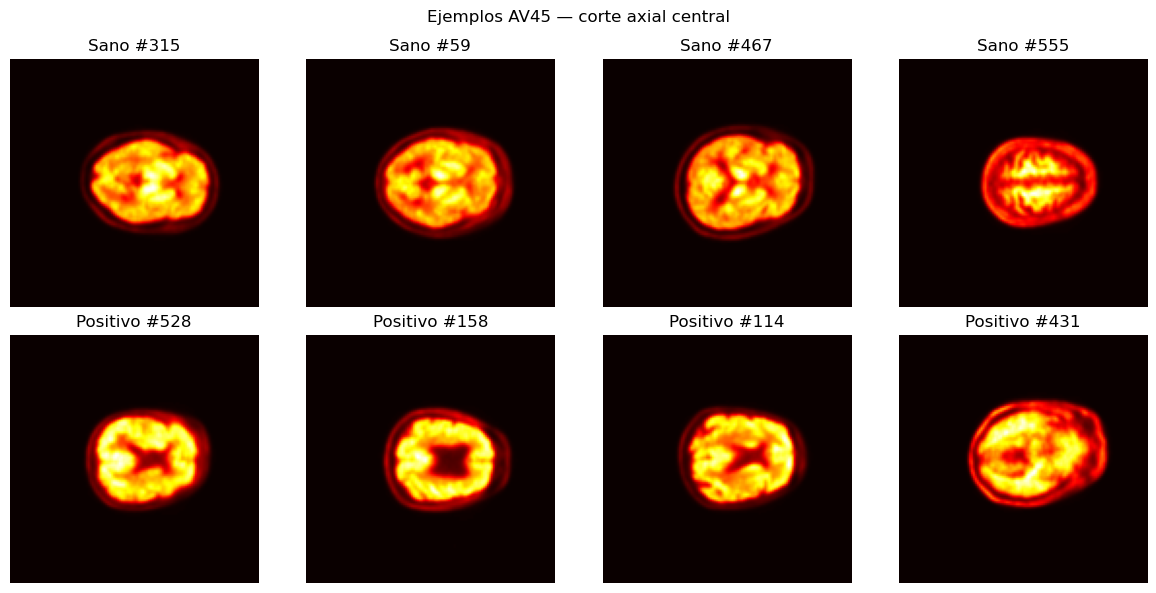

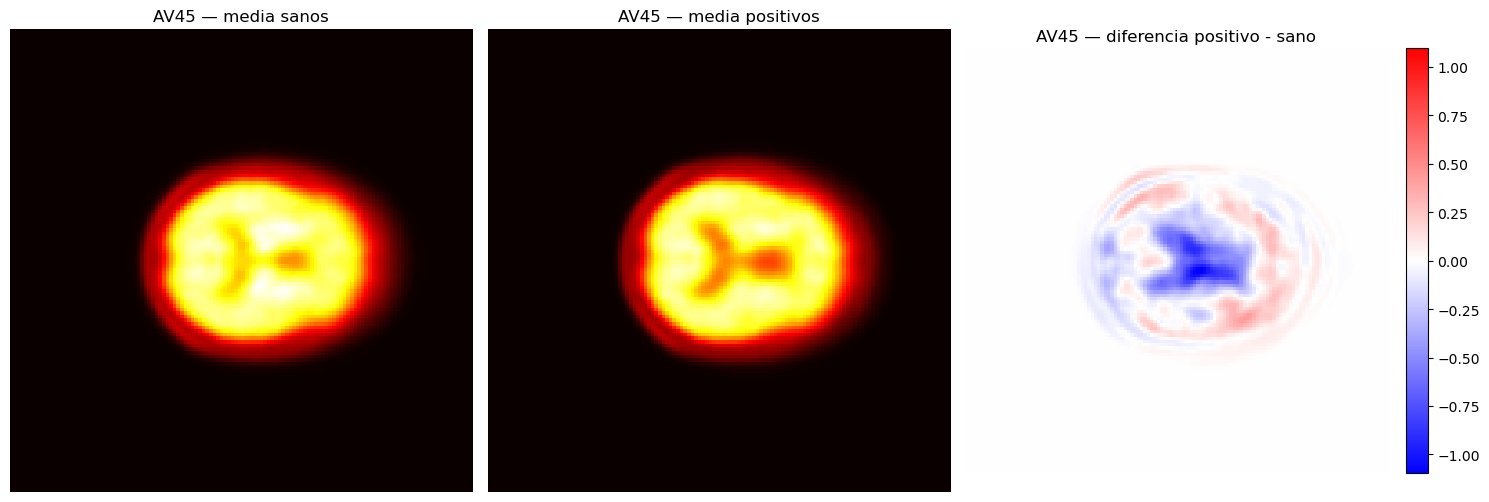

In [10]:
visualizar_ejemplos(X_av45, y_av45, "AV45", n=4)
visualizar_medias(X_av45, y_av45, "AV45")


## 8. Comprovar una imatge original respecte de la seva versió processada

Aquesta cel·la permet comparar un NIfTI AV45 original amb el volum guardat a `X_av45`.

La comparació és útil per distingir si un artefacte prové de la imatge original o del preprocessament.


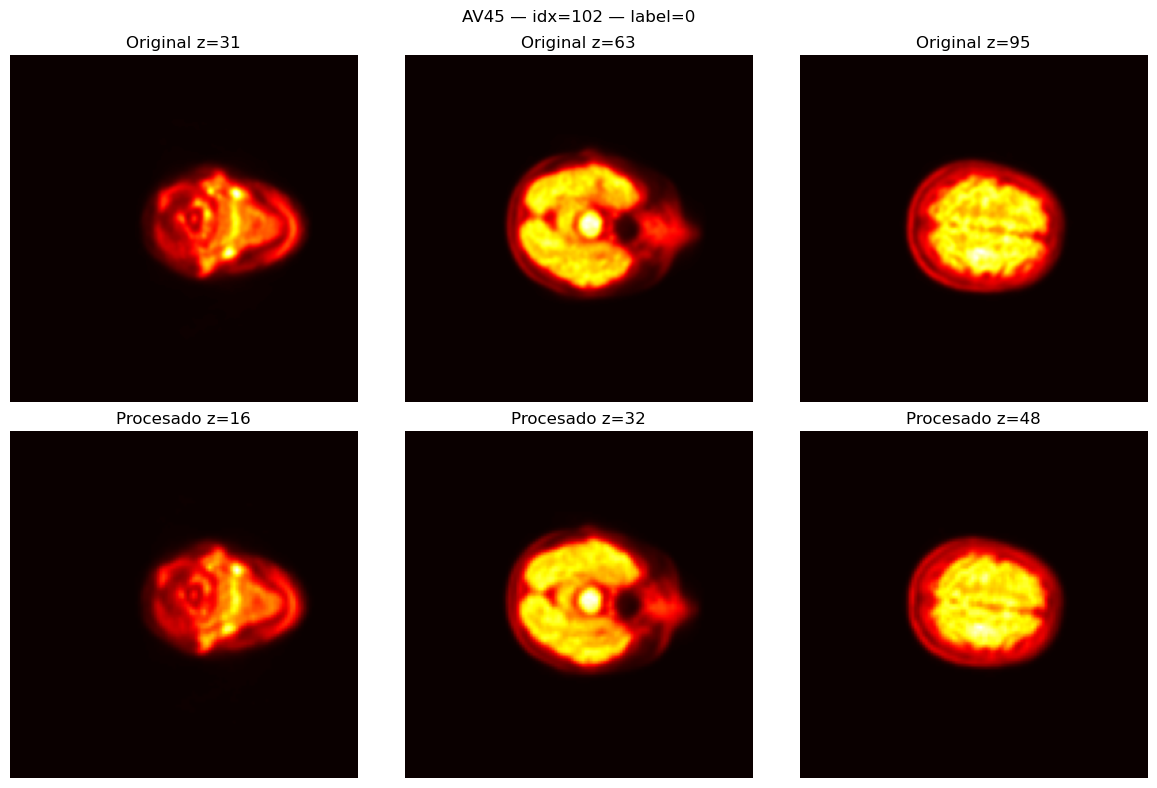

In [11]:
def comparar_original_vs_procesado(meta, X, idx=0):
    """
    Funció auxiliar `comparar_original_vs_procesado` utilitzada dins del flux de treball de la notebook.
    
    Aquesta funció encapsula una part del processament per mantenir el codi més
    organitzat, reutilitzable i fàcil d'interpretar durant l'anàlisi.
    
    Paràmetres:
        meta: Paràmetre d'entrada utilitzat per la funció.
        X: Paràmetre d'entrada utilitzat per la funció.
        idx: Paràmetre d'entrada utilitzat per la funció.
    
    Retorna:
        Resultat generat per la funció segons l'operació implementada.
    """
    ruta = meta.iloc[idx]["ruta_imagen"]
    tracer = meta.iloc[idx]["tracer"]
    label = meta.iloc[idx]["label_binaria"]

    original = nib.load(ruta).get_fdata(dtype=np.float32)

    if original.ndim == 4:
        original = np.nanmean(original, axis=3)

    processed = X[idx]

    if processed.ndim == 4:
        processed = processed[0]

    zs_orig = [
        original.shape[2] // 4,
        original.shape[2] // 2,
        3 * original.shape[2] // 4
    ]

    zs_proc = [
        processed.shape[2] // 4,
        processed.shape[2] // 2,
        3 * processed.shape[2] // 4
    ]

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    for j, z in enumerate(zs_orig):
        axes[0, j].imshow(original[:, :, z], cmap="hot")
        axes[0, j].set_title(f"Original z={z}")
        axes[0, j].axis("off")

    for j, z in enumerate(zs_proc):
        axes[1, j].imshow(processed[:, :, z], cmap="hot")
        axes[1, j].set_title(f"Procesado z={z}")
        axes[1, j].axis("off")

    plt.suptitle(f"{tracer} — idx={idx} — label={label}")
    plt.tight_layout()
    plt.show()


# Exemple:
comparar_original_vs_procesado(meta_av45, X_av45, idx=102)


## 9. Comparativa entre imatge original i preprocessada

Aquesta secció permet comprovar visualment que el preprocessament manté l'estructura general de la imatge PET. Es compara una imatge AV45 original, en format NIfTI, amb la seva versió final preprocessada i redimensionada a `128 × 128 × 64` voxels.

Es mostren els talls centrals en els tres plans principals: sagital, coronal i axial. La imatge original es visualitza en la seva resolució original i la imatge preprocessada en la resolució utilitzada posteriorment pels models.

Índice: 0
OASISID: OAS30001
Etiqueta: Sano
Ruta original: D:\Universidad\TFG\OASIS\av45\www.nitrc.org\ir\OAS30001_AV45_d2430\pet1\NIFTI\sub-OAS30001_ses-d2430_acq-AV45_pet.nii.gz
Shape original: (256, 256, 127)
Shape preprocessada: (128, 128, 64)
Figura guardada en: D:\Universidad\TFG\OASIS\figuras\originalVSprocessed.png


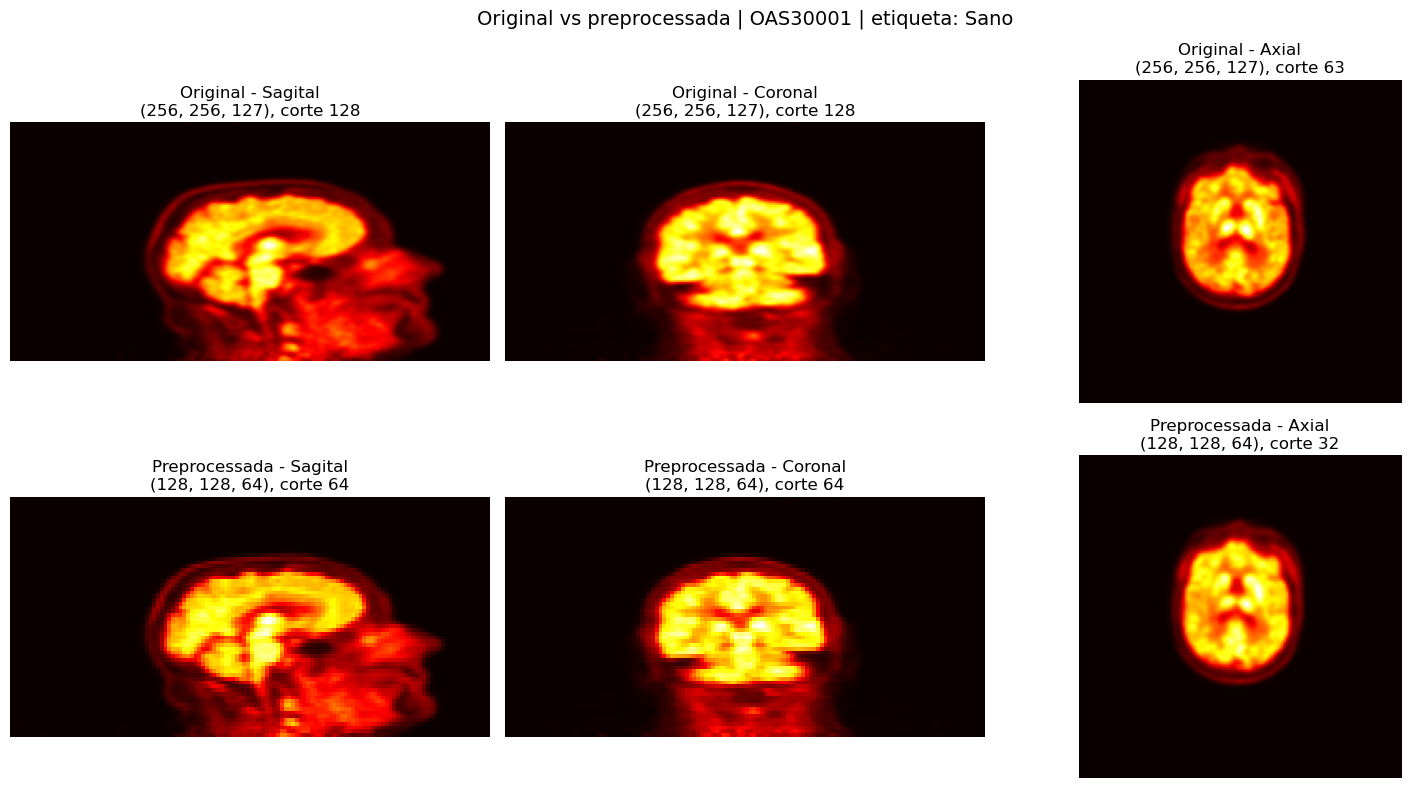

In [ ]:
# ============================================================
# 9. COMPARATIVA ENTRE ORIGINAL I PREPROCESSADA AV45
# ============================================================

import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt


def cargar_original_3d(ruta_nifti):
    """Carrega una imatge NIfTI i la converteix a volum 3D si és 4D."""
    img = nib.load(ruta_nifti)
    data = img.get_fdata()

    if data.ndim == 4:
        data = data.mean(axis=3)

    return data.astype(np.float32)


def extraer_preprocesada(X, idx):
    """Extreu una imatge preprocessada des de X, eliminant el canal si existeix."""
    vol = X[idx]

    # Cas típic per a CNN: (1, X, Y, Z)
    if vol.ndim == 4 and vol.shape[0] == 1:
        vol = vol[0]

    vol = np.squeeze(vol).astype(np.float32)

    if vol.ndim != 3:
        raise ValueError(f"La imagen preprocessada debe ser 3D. Shape obtenida: {vol.shape}")

    return vol


def cortes_centrales(vol):
    """Retorna els talls centrals sagital, coronal i axial d'un volum 3D."""
    x_mid = vol.shape[0] // 2
    y_mid = vol.shape[1] // 2
    z_mid = vol.shape[2] // 2

    cortes = {
        "Sagital": vol[x_mid, :, :],
        "Coronal": vol[:, y_mid, :],
        "Axial": vol[:, :, z_mid]
    }

    indices = {
        "Sagital": x_mid,
        "Coronal": y_mid,
        "Axial": z_mid
    }

    return cortes, indices


def mostrar_comparativa_original_preprocesada(
    meta,
    X,
    idx=0,
    cmap="hot",
    guardar=False,
    nombre_figura="originalVSprocessed.png"
):
    """
    Muestra una comparación entre la imagen original y la imagen preprocessada.

    Filas:
    - fila 1: imagen original NIfTI, en su resolución original.
    - fila 2: imagen preprocessada, en la resolución final del dataset.

    Columnas:
    - sagital,
    - coronal,
    - axial.
    """
    meta_reset = meta.reset_index(drop=True)

    if "ruta_imagen" not in meta_reset.columns:
        raise ValueError("El metadata debe contener una columna llamada 'ruta_imagen'.")

    ruta_original = meta_reset.iloc[idx]["ruta_imagen"]
    original_3d = cargar_original_3d(ruta_original)
    preproc_3d = extraer_preprocesada(X, idx)

    cortes_original, indices_original = cortes_centrales(original_3d)
    cortes_preproc, indices_preproc = cortes_centrales(preproc_3d)

    oasisid = meta_reset.iloc[idx].get("OASISID", "No disponible")
    etiqueta = meta_reset.iloc[idx].get("label_binaria", "No disponible")
    etiqueta_txt = "Sano" if etiqueta == 0 else "Deteriorament" if etiqueta == 1 else str(etiqueta)

    print("Índice:", idx)
    print("OASISID:", oasisid)
    print("Etiqueta:", etiqueta_txt)
    print("Ruta original:", ruta_original)
    print("Shape original:", original_3d.shape)
    print("Shape preprocessada:", preproc_3d.shape)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    planos = ["Sagital", "Coronal", "Axial"]

    for j, plano in enumerate(planos):
        axes[0, j].imshow(np.rot90(cortes_original[plano]), cmap=cmap)
        axes[0, j].set_title(f"Original - {plano}\n{original_3d.shape}, corte {indices_original[plano]}")
        axes[0, j].axis("off")

        axes[1, j].imshow(np.rot90(cortes_preproc[plano]), cmap=cmap)
        axes[1, j].set_title(f"Preprocessada - {plano}\n{preproc_3d.shape}, corte {indices_preproc[plano]}")
        axes[1, j].axis("off")

    plt.suptitle(
        f"Original vs preprocessada | {oasisid} | etiqueta: {etiqueta_txt}",
        fontsize=14
    )
    plt.tight_layout()

    if guardar:
        carpeta_figuras = os.path.join(OUT_DIR, "figuras")
        os.makedirs(carpeta_figuras, exist_ok=True)
        ruta_salida = os.path.join(carpeta_figuras, nombre_figura)
        plt.savefig(ruta_salida, dpi=300, bbox_inches="tight")
        print("Figura guardada en:", ruta_salida)

    plt.show()

idx_memoria = 0
mostrar_comparativa_original_preprocesada(
    meta=meta_av45,
    X=X_av45,
    idx=idx_memoria,
    guardar=True,
    nombre_figura="originalVSprocessed.png"
)
